In [1]:
import collections
import json
import pickle
import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd

from boilerplate import clip_before, clip_after, clip_at, filter_boilerplate


In [50]:
# bert_topic_starter.py

from bertopic import BERTopic
import pandas as pd
import re
from sklearn.feature_extraction.text import CountVectorizer
from sentence_transformers import SentenceTransformer

df = pd.read_csv("/Users/tylermckenzie/Desktop/LLM-MPOX/relevant_topic_articles.csv")

# added title because its probabily important, adding a period after each title to keep meaning
df["text"] = df["title"].fillna('') + ". " + df["text"].fillna('')
# removing URLS 
def clean_text(text):
    text = re.sub(r"http\S+|www\S+|https\S+", '', text)  # remove URLs
    return text

df["text_clean"] = df["text"].apply(clean_text)

from bertopic.vectorizers import ClassTfidfTransformer
ctfidf_model = ClassTfidfTransformer(reduce_frequent_words=True)
topic_model = BERTopic(ctfidf_model=ctfidf_model)

topics, probs = topic_model.fit_transform(df["text_clean"])



df["bertopic_topic"] = topics
df.to_csv("mpox_with_bertopic.csv", index=False)


In [51]:
topic_info = topic_model.get_topic_info()
topic_info[topic_info.Topic != -1].head(10)

,Topic,Count,Name,Representation,Representative_Docs
1,0,130,0_gay_men_sex_aids,"[gay, men, sex, aids, hiv, sexual, community, ...","[Lesions, headaches, debilitating pain: Gay me..."
2,1,118,1_virus_viruses_humans_animals,"[virus, viruses, humans, animals, smallpox, co...","[What is monkeypox?. The virus, which is simil..."
3,2,88,2_committee_tedros_international_emergency,"[committee, tedros, international, emergency, ...",[WHO Boss Tedros Officially Declares Monkeypox...
4,3,87,3_case_minnesota_patient_massachusetts,"[case, minnesota, patient, massachusetts, cont...",[California has its first suspected monkeypox ...
5,4,83,4_children_students_schools_school,"[children, students, schools, school, parents,...",[Here's What You Should Know About Monkeypox I...
6,5,71,5_uk_ukhsa_nhs_london,"[uk, ukhsa, nhs, london, security, agency, eng...",[‘Now we have to deal with it’: what’s going o...
7,6,68,6_covid_pandemic_conspiracy_fauci,"[covid, pandemic, conspiracy, fauci, you, covi...",[Illumina Helped the World Fight COVID-19. Now...
8,7,66,7_emergency_declaration_administration_response,"[emergency, declaration, administration, respo...","[Monkeypox: What we know about the outbreak, v..."
9,8,66,8_black_white_vaccine_hispanic,"[black, white, vaccine, hispanic, new, doses, ...","[As Monkeypox Cases Go Down, Testing Must Go U..."
10,9,58,9_bavarian_nordic_company_doses,"[bavarian, nordic, company, doses, million, va...",[How the U.S. let 20 million doses of monkeypo...


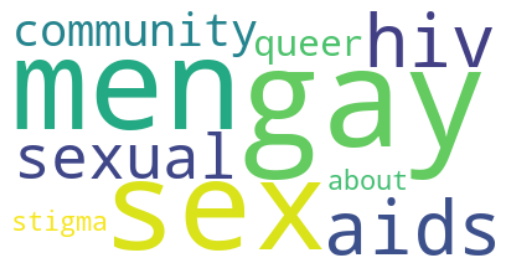

None


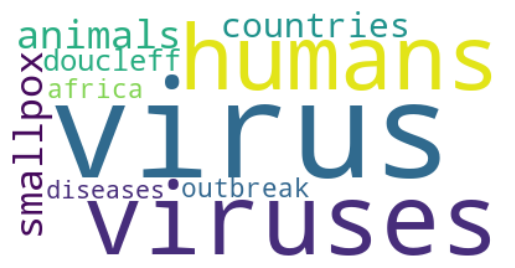

None


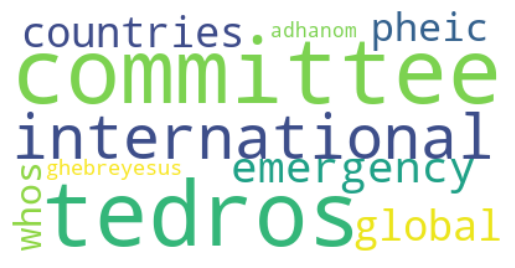

None


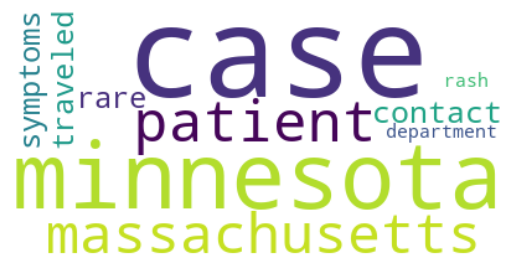

None


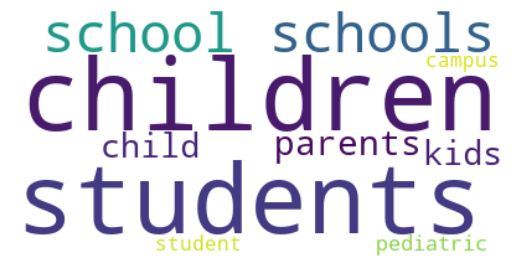

None


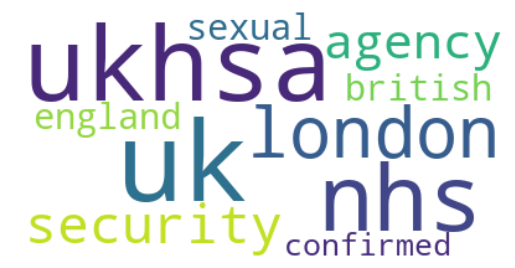

None


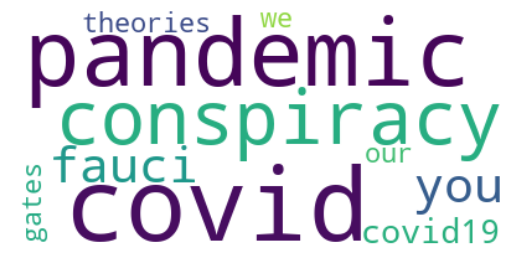

None


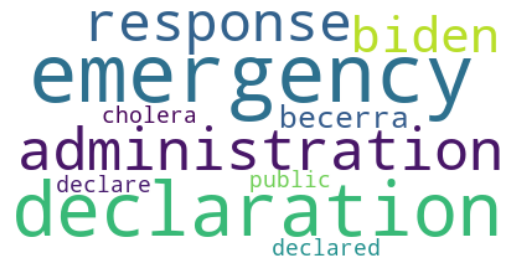

None


In [52]:
from sklearn.datasets import fetch_20newsgroups
from bertopic import BERTopic
from wordcloud import WordCloud
import matplotlib.pyplot as plt

def create_wordcloud(topic_model, topic):
    text = {word: value for word, value in topic_model.get_topic(topic)}
    wc = WordCloud(background_color="white", max_words=1000)
    wc.generate_from_frequencies(text)
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.show()



# printing topics
print(create_wordcloud(topic_model, topic=0))
print(create_wordcloud(topic_model, topic=1))
print(create_wordcloud(topic_model, topic=2))
print(create_wordcloud(topic_model, topic=3))
print(create_wordcloud(topic_model, topic=4))
print(create_wordcloud(topic_model, topic=5))
print(create_wordcloud(topic_model, topic=6))
print(create_wordcloud(topic_model, topic=7))

# attempt number 2

In [46]:
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import CountVectorizer
from bertopic import BERTopic

embedding_model = SentenceTransformer("all-MiniLM-L6-v2")
vectorizer_model = CountVectorizer(ngram_range=(1, 2), stop_words="english")

topic_model = BERTopic(embedding_model=embedding_model,
                       vectorizer_model=vectorizer_model,
                       min_topic_size=20, ctfidf_model=ctfidf_model)
topics, probs = topic_model.fit_transform(df["text_clean"])

In [34]:
topic_info = topic_model.get_topic_info()
topic_info[topic_info.Topic != -1].head(10)

,Topic,Count,Name,Representation,Representative_Docs
1,0,448,0_vaccine_monkeypox vaccine_vaccines_monkeypox...,"[vaccine, monkeypox vaccine, vaccines, monkeyp...",[white house sends extra monkeypox vaccines ah...
2,1,399,1_monkeypox cases_cases_case_monkeypox case,"[monkeypox cases, cases, case, monkeypox case,...",[health officials confirm first us case of mon...
3,2,175,2_sex_gay_men_gay men,"[sex, gay, men, gay men, lgbtq, community, sex...",[cdc gently suggests that gay men have fewer s...
4,3,118,3_covid_pandemic_covid monkeypox_monkeypox covid,"[covid, pandemic, covid monkeypox, monkeypox c...",[trevor noah laments monkeypox declaration say...
5,4,107,4_emergency_health emergency_monkeypox global_...,"[emergency, health emergency, monkeypox global...",[us declares monkeypox a public health emergen...
6,5,84,5_know monkeypox_like_monkeypox myths_monkeypo...,"[know monkeypox, like, monkeypox myths, monkey...",[gottlieb window for containing monkeypox prob...
7,6,72,6_symptoms_monkeypox symptoms_treatment_look,"[symptoms, monkeypox symptoms, treatment, look...",[monkeypox symptoms are different from previou...
8,7,71,7_children_students_school_schools,"[children, students, school, schools, monkeypo...",[adult at day care tests positive for monkeypo...
9,8,51,8_rename_rename monkeypox_stigma_stigmatizing,"[rename, rename monkeypox, stigma, stigmatizin...",[painful and racist history nyc health czar de...
10,9,49,9_monkeypox outbreak_outbreak_outbreak global_...,"[monkeypox outbreak, outbreak, outbreak global...",[who monkeypox emergency committee to reconve...


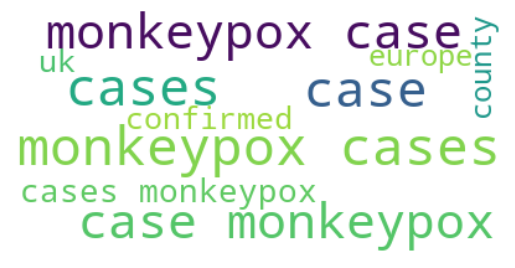

None


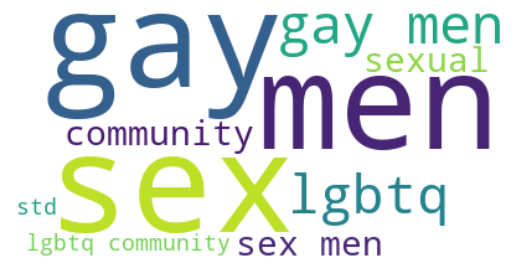

None


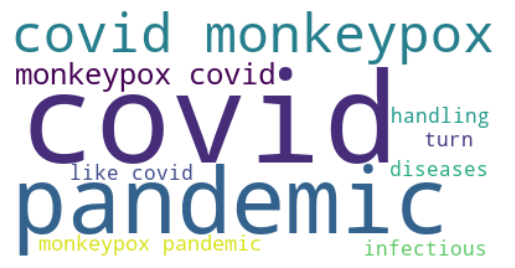

None


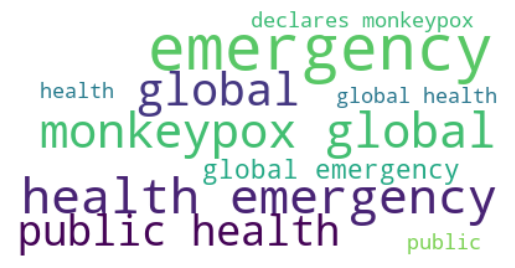

None


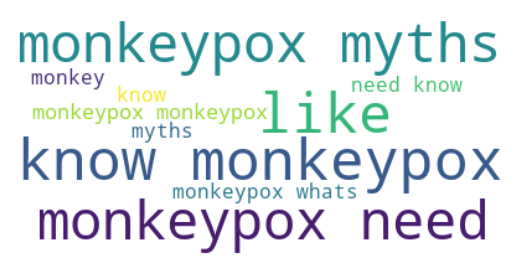

None


In [35]:
from sklearn.datasets import fetch_20newsgroups
from bertopic import BERTopic
from wordcloud import WordCloud
import matplotlib.pyplot as plt

def create_wordcloud(topic_model, topic):
    text = {word: value for word, value in topic_model.get_topic(topic)}
    wc = WordCloud(background_color="white", max_words=1000)
    wc.generate_from_frequencies(text)
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.show()



# printing topics
print(create_wordcloud(topic_model, topic=1))
print(create_wordcloud(topic_model, topic=2))
print(create_wordcloud(topic_model, topic=3))
print(create_wordcloud(topic_model, topic=4))
print(create_wordcloud(topic_model, topic=5))